In [25]:
#!/usr/bin/env python3
"""
GP + Dynamic Bayesian Network credit risk model (paper-style)
Python 3.8, pgmpy 0.1.20 recommended.

Pipeline:
 1. Load German Credit dataset.
 2. Scale features (StandardScaler + MinMax).
 3. RBM learns K latent binary/real activations.
 4. Discretize activations into symbols (bins).
 5. Build 2-slice DBN:
        Hi_t  -> Hi_t1
        Class -> Hi_t1
    Roots: Hi_t, Class.
 6. Use GP (DEAP) to tune:
        - n_components (latent size)
        - rbm_lr
        - rbm_iter
        - n_bins (symbolization)
 7. Evaluate with exact inference on held-out test set.
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import random

from sklearn.preprocessing import StandardScaler, MinMaxScaler, KBinsDiscretizer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import BernoulliRBM

from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

from deap import base, creator, tools, algorithms

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [26]:
# 1. Data loading & preprocessing
# -----------------------------
def load_german():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    df = pd.read_csv(url, sep=" ", header=None)
    X = df.iloc[:, :-1].apply(pd.to_numeric, errors="coerce").fillna(0)
    y = df.iloc[:, -1].replace({1: 1, 2: 0}).astype(int)  # 1=good (CA), 0=bad (NCA)
    return X.values, y.values


X, y = load_german()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_SEED
)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

minmax = MinMaxScaler()
X_train_minmax = minmax.fit_transform(X_train_scaled)
X_test_minmax = minmax.transform(X_test_scaled)



In [27]:
# 2. RBM + discretization
# -----------------------------
def rbm_and_symbolize(X_tr, X_te, n_components=8, lr=0.05, n_iter=10, n_bins=3):
    """
    Train RBM, transform train/test, then discretize latent activations
    into ordinal symbols 0 .. n_bins-1.
    """
    rbm = BernoulliRBM(
        n_components=int(n_components),
        learning_rate=float(lr),
        n_iter=int(n_iter),
        random_state=RANDOM_SEED,
        verbose=False,
    )
    rbm.fit(X_tr)

    H_tr = rbm.transform(X_tr)
    H_te = rbm.transform(X_te)

    kb = KBinsDiscretizer(
        n_bins=int(n_bins), encode="ordinal", strategy="quantile"
    )
    H_tr_disc = kb.fit_transform(H_tr).astype(int)
    H_te_disc = kb.transform(H_te).astype(int)

    k = H_tr_disc.shape[1]
    cols = [f"H{i+1}" for i in range(k)]
    df_tr = pd.DataFrame(H_tr_disc, columns=cols)
    df_te = pd.DataFrame(H_te_disc, columns=cols)
    return df_tr, df_te, rbm



In [28]:
# 3. Build 2-slice DBN structure
# -----------------------------
def build_dbn_structure(k):
    """
    k latent variables -> we create:
      H1_t, ..., Hk_t, H1_t1, ..., Hk_t1, Class

    Edges:
      Hi_t  -> Hi_t1
      Class -> Hi_t1
    """
    edges = []
    for i in range(1, k + 1):
        h_t = f"H{i}_t"
        h_t1 = f"H{i}_t1"
        edges.append((h_t, h_t1))
        edges.append(("Class", h_t1))

    return edges


def prepare_dbn_data(df_latent, y_vec):
    """
    Given df_latent with columns H1..Hk (discrete ints), create:
      - columns H1_t..Hk_t (copy)
      - columns H1_t1..Hk_t1 (copy again, representing next slice)
      - Class column
    """
    k = df_latent.shape[1]
    df = pd.DataFrame()

    for i in range(1, k + 1):
        h = f"H{i}"
        df[f"H{i}_t"] = df_latent[h].values
        df[f"H{i}_t1"] = df_latent[h].values  # same row acts as next-slice symbol

    df["Class"] = y_vec
    return df


def train_dbn(df_train_full):
    """
    Fit DBN (2-slice BN) using MaximumLikelihoodEstimator.
    """
    # determine k from columns
    k = sum(1 for c in df_train_full.columns if c.endswith("_t") and c.startswith("H"))
    edges = build_dbn_structure(k)

    model = BayesianNetwork(edges)
    model.fit(df_train_full, estimator=MaximumLikelihoodEstimator)
    infer = VariableElimination(model)
    return model, infer


def predict_dbn(model, infer, df_test_latent):
    """
    For each test sample (latent discrete features),
    build evidence dict for Hi_t and Hi_t1, then query P(Class | evidence).
    """
    k = df_test_latent.shape[1]
    preds = []
    for _, row in df_test_latent.iterrows():
        ev = {}
        for i in range(1, k + 1):
            h = f"H{i}"
            val = int(row[h])
            ev[f"H{i}_t"] = val
            ev[f"H{i}_t1"] = val
        try:
            q = infer.query(["Class"], evidence=ev)
            preds.append(int(q.values.argmax()))
        except Exception:
            preds.append(1)  # default to majority (good credit)
    return np.array(preds)



In [29]:
# 4. Fitness function for GP
# -----------------------------
def evaluate_config(n_components, lr, n_iter, n_bins, cv_splits=3):
    """
    Evaluate one configuration with StratifiedKFold on training data.
    """
    n_components = int(max(2, min(16, round(n_components))))
    lr = float(max(0.001, min(0.3, lr)))
    n_iter = int(max(3, min(40, round(n_iter))))
    n_bins = int(max(2, min(5, round(n_bins))))

    skf = StratifiedKFold(
        n_splits=cv_splits, shuffle=True, random_state=RANDOM_SEED
    )
    accs = []

    for tr_idx, val_idx in skf.split(X_train_minmax, y_train):
        Xtr = X_train_minmax[tr_idx]
        Xval = X_train_minmax[val_idx]
        ytr = y_train[tr_idx]
        yval = y_train[val_idx]

        try:
            df_lat_tr, df_lat_val, rbm_local = rbm_and_symbolize(
                Xtr, Xval, n_components=n_components, lr=lr, n_iter=n_iter, n_bins=n_bins
            )
        except Exception:
            accs.append(0.0)
            continue

        # Build DBN training data (two slices + Class)
        df_dbn_tr = prepare_dbn_data(df_lat_tr, ytr)
        try:
            model, infer = train_dbn(df_dbn_tr)
        except Exception:
            accs.append(0.0)
            continue

        # For validation, do only latent discretization (same as training) and DBN inference
        # Build temporary df_dbn_val (two slices, no Class)
        # We re-use df_lat_val as evidence; prediction uses infer
        y_pred = []
        k = df_lat_tr.shape[1]
        for _, row in df_lat_val.iterrows():
            ev = {}
            for i in range(1, k + 1):
                val = int(row[f"H{i}"])
                ev[f"H{i}_t"] = val
                ev[f"H{i}_t1"] = val
            try:
                q = infer.query(["Class"], evidence=ev)
                y_pred.append(int(q.values.argmax()))
            except Exception:
                y_pred.append(1)
        accs.append(accuracy_score(yval, y_pred))

    return float(np.mean(accs)) if accs else 0.0



In [30]:
# 5. GP setup (DEAP)
# -----------------------------
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("n_comp_gene", random.randint, 4, 16)
toolbox.register("lr_gene", random.uniform, 0.01, 0.25)
toolbox.register("n_iter_gene", random.randint, 5, 30)
toolbox.register("n_bins_gene", random.randint, 2, 5)

def init_ind():
    return creator.Individual([
        toolbox.n_comp_gene(),
        toolbox.lr_gene(),
        toolbox.n_iter_gene(),
        toolbox.n_bins_gene()
    ])

toolbox.register("individual", init_ind)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_individual(ind):
    n_comp, lr, n_it, n_bins = ind
    acc = evaluate_config(n_comp, lr, n_it, n_bins, cv_splits=3)
    return (acc,)

toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxTwoPoint)

def mut_ind(ind, indpb=0.3):
    if random.random() < indpb:
        ind[0] = int(np.clip(ind[0] + random.randint(-2, 2), 4, 16))
    if random.random() < indpb:
        ind[1] = float(np.clip(ind[1] + random.uniform(-0.02, 0.02), 0.01, 0.25))
    if random.random() < indpb:
        ind[2] = int(np.clip(ind[2] + random.randint(-4, 4), 5, 30))
    if random.random() < indpb:
        ind[3] = int(np.clip(ind[3] + random.randint(-1, 1), 2, 5))
    return (ind,)

toolbox.register("mutate", mut_ind)
toolbox.register("select", tools.selTournament, tournsize=3)


def run_gp(pop_size=8, gens=4):
    pop = toolbox.population(n=pop_size)

    # initial evaluation
    for ind in pop:
        ind.fitness.values = toolbox.evaluate(ind)
        print("ind:", ind, " -> fitness:", ind.fitness.values[0])

    for g in range(gens):
        print(f"\n-- GP Generation {g+1}/{gens} --")
        offspring = algorithms.varAnd(pop, toolbox, cxpb=0.6, mutpb=0.3)
        invalid = [ind for ind in offspring if not ind.fitness.valid]
        print(" Evaluating", len(invalid), "offspring...")
        for ind in invalid:
            ind.fitness.values = toolbox.evaluate(ind)
        pop = toolbox.select(offspring, k=len(pop))
        best = tools.selBest(pop, k=1)[0]
        print(" Best so far:", best, "acc:", best.fitness.values[0])

    best_final = tools.selBest(pop, k=1)[0]
    return best_final



=== Baseline (fixed params) ===
Baseline accuracy: 0.7
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        90
           1     0.7000    1.0000    0.8235       210

    accuracy                         0.7000       300
   macro avg     0.3500    0.5000    0.4118       300
weighted avg     0.4900    0.7000    0.5765       300


=== Running GP to tune RBM + symbolization ===
Baseline accuracy: 0.7
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        90
           1     0.7000    1.0000    0.8235       210

    accuracy                         0.7000       300
   macro avg     0.3500    0.5000    0.4118       300
weighted avg     0.4900    0.7000    0.5765       300


=== Running GP to tune RBM + symbolization ===
ind: [14, 0.03671945635976329, 28, 4]  -> fitness: 0.6999987772519961
ind: [14, 0.03671945635976329, 28, 4]  -> fitness: 0.6999987772519961
ind: [7, 0.06357057715571746, 28

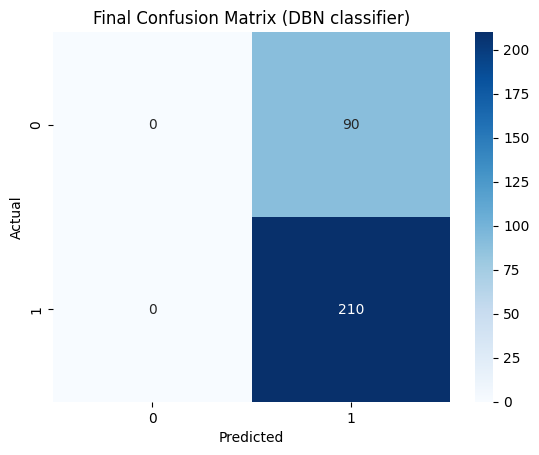


=== Some learned CPDs (for report) ===
+---------+----------+
| H1_t(0) | 0.332857 |
+---------+----------+
| H1_t(1) | 0.332857 |
+---------+----------+
| H1_t(2) | 0.334286 |
+---------+----------+
------------------------------------------------------------
+----------+----------+----------+----------+----------+----------+----------+
| Class    | Class(0) | Class(0) | Class(0) | Class(1) | Class(1) | Class(1) |
+----------+----------+----------+----------+----------+----------+----------+
| H1_t     | H1_t(0)  | H1_t(1)  | H1_t(2)  | H1_t(0)  | H1_t(1)  | H1_t(2)  |
+----------+----------+----------+----------+----------+----------+----------+
| H1_t1(0) | 1.0      | 0.0      | 0.0      | 1.0      | 0.0      | 0.0      |
+----------+----------+----------+----------+----------+----------+----------+
| H1_t1(1) | 0.0      | 1.0      | 0.0      | 0.0      | 1.0      | 0.0      |
+----------+----------+----------+----------+----------+----------+----------+
| H1_t1(2) | 0.0      | 0.0

In [31]:
# 6. Main
# -----------------------------
if __name__ == "__main__":
    print("=== Baseline (fixed params) ===")
    base_df_tr, base_df_te, base_rbm = rbm_and_symbolize(
        X_train_minmax, X_test_minmax,
        n_components=8, lr=0.05, n_iter=10, n_bins=3
    )
    base_dbn_tr = prepare_dbn_data(base_df_tr, y_train)
    base_model, base_infer = train_dbn(base_dbn_tr)
    y_base = predict_dbn(base_model, base_infer, base_df_te)
    print("Baseline accuracy:", accuracy_score(y_test, y_base))
    print(classification_report(y_test, y_base, digits=4))

    print("\n=== Running GP to tune RBM + symbolization ===")
    best = run_gp(pop_size=10, gens=4)
    print("\nBest individual:", best, " fitness:", best.fitness.values[0])

    best_ncomp, best_lr, best_niter, best_nbins = best
    print("\n=== Training final DBN with best hyperparameters ===")
    df_tr_lat, df_te_lat, rbm_final = rbm_and_symbolize(
        X_train_minmax, X_test_minmax,
        n_components=int(best_ncomp),
        lr=float(best_lr),
        n_iter=int(best_niter),
        n_bins=int(best_nbins),
    )
    df_tr_dbn = prepare_dbn_data(df_tr_lat, y_train)
    model_final, infer_final = train_dbn(df_tr_dbn)
    y_pred_final = predict_dbn(model_final, infer_final, df_te_lat)

    print("\n=== FINAL TEST RESULTS (DBN classifier) ===")
    print("Accuracy:", accuracy_score(y_test, y_pred_final))
    print(classification_report(y_test, y_pred_final, digits=4))

    cm = confusion_matrix(y_test, y_pred_final)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Final Confusion Matrix (DBN classifier)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Show some CPDs for report
    print("\n=== Some learned CPDs (for report) ===")
    for cpd in model_final.get_cpds()[:5]:
        print(cpd)
        print("-" * 60)